$$\textbf{Tarea 5 y 6}$$
$$\textbf{Métodos de Optimización}$$
______________
Problema 4. Use ramificación y acotamiento.

  $$\max z = 11x_1 +8x_2+7x_3$$  
    sujeto a

\begin{align*}
  5x_1+4x_2+3x_3 &\leq 21\\
  2x_1 +3x_2+4x_3 &\leq 17\\
  x_1,x_2,x_3 \in \mathbb{Z}_{\geq 0}.
\end{align*}

In [ ]:
install.packages("linprog")
install.packages("fractional")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘lpSolve’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: lpSolve



In [ ]:
library(linprog)
library(fractional)

**Solución.**

In [ ]:
#Definir el problema de maximización

C <- c(11.0,8.0, 7.0)
A <- matrix(c(5, 4, 3,
              2, 3, 4), nrow = 2, byrow = TRUE)
B <- c(21, 17)
direction <- c("<=", "<=")
PL <- lp(direction = "max",
         objective.in = C,
         const.mat = A,
         const.dir = direction,
         const.rhs = B)
         #all.int = T - para programación ent. directo
PL
round(PL$solution, 2)

Success: the objective function is 47.42857 

[1] 2.36 0.00 3.07

La solución no es entera. Empezamos la ramificación con $x_1 \leq 2$ y $x_1 \geq 3$

In [ ]:
#Rama 1 x_1 <= 2

A <- matrix(c(5, 4, 3,
              2, 3, 4,
              1, 0, 0), nrow = 3, byrow = TRUE)
B <- c(21, 17, 2)
direction <- c("<=", "<=", "<=")
PL <- lp(direction = "max",
         objective.in = C,
         const.mat = A,
         const.dir = direction,
         const.rhs = B)
         #all.int = T - para programación ent. directo
PL
round(PL$solution, 2)

Success: the objective function is 46.71429 

[1] 2.00 0.71 2.71

In [ ]:
#Rama 2 x_1 >= 3

A <- matrix(c(5, 4, 3,
              2, 3, 4,
              -1, 0, 0), nrow = 3, byrow = TRUE)
B <- c(21, 17, -3)
direction <- c("<=", "<=", "<=")
PL <- lp(direction = "max",
         objective.in = C,
         const.mat = A,
         const.dir = direction,
         const.rhs = B)
         #all.int = T - para programación ent. directo
PL
round(PL$solution, 2)

Success: the objective function is 47 

[1] 3 0 2

Aquí la solución $(3, 0, 2)$ con $z = 47$ si es entera, se considera como solución óptima candidata. Continuamos la ramificación desde el nodo $x_2 \leq 2$. Ahora consideramos $x_2 \leq 0$ y $x_2 \geq 1$.

In [ ]:
#Rama 1 x_1 <= 2, x_2<= 0

A <- matrix(c(5, 4, 3,
              2, 3, 4,
              1, 0, 0,
              0, 1, 0), nrow = 4, byrow = TRUE)
B <- c(21, 17, 2, 0)
direction <- c("<=", "<=", "<=", "<=")
PL <- lp(direction = "max",
         objective.in = C,
         const.mat = A,
         const.dir = direction,
         const.rhs = B)
         #all.int = T - para programación ent. directo
PL
round(PL$solution, 2)

Success: the objective function is 44.75 

[1] 2.00 0.00 3.25

In [ ]:
#Rama 1 x_1 <= 2, x_2 >= 1

A <- matrix(c(5, 4, 3,
              2, 3, 4,
              1, 0, 0,
              0, -1, 0), nrow = 4, byrow = TRUE)
B <- c(21, 17, 2, -1)
direction <- c("<=", "<=", "<=", "<=")
PL <- lp(direction = "max",
         objective.in = C,
         const.mat = A,
         const.dir = direction,
         const.rhs = B)
         #all.int = T - para programación ent. directo
PL
round(PL$solution, 2)

Success: the objective function is 46.42857 

[1] 1.86 1.00 2.57

Dado que al suponer $x_2 \geq 1$ la solución no mejoró, no vale la pena seguir con la ramificación. Continuamos ramificando bajo el supuesto $x_2\leq 0$ y ahora se considera $x_3 \leq 3$ y $x_3 \geq 4$.

In [ ]:
#Rama 1 x_1 <= 2, x_2<= 0, x_3 <= 3

A <- matrix(c(5, 4, 3,
              2, 3, 4,
              1, 0, 0,
              0, 1, 0,
              0, 0, 1), nrow = 5, byrow = TRUE)
B <- c(21, 17, 2, 0, 3)
direction <- c("<=", "<=", "<=", "<=", "<=")
PL <- lp(direction = "max",
         objective.in = C,
         const.mat = A,
         const.dir = direction,
         const.rhs = B)
         #all.int = T - para programación ent. directo
PL
round(PL$solution, 2)

Success: the objective function is 43 

[1] 2 0 3

La solución $(2, 0, 3)$ si entera, sin embargo, no se ha maximizado la función objeto, pues $z=43 <47$.

In [ ]:
#Rama 1 x_1 <= 2, x_2<= 0, x_3 >= 4

A <- matrix(c(5, 4, 3,
              2, 3, 4,
              1, 0, 0,
              0, 1, 0,
              0, 0, -1), nrow = 5, byrow = TRUE)
B <- c(21, 17, 2, 0, -4)
direction <- c("<=", "<=", "<=", "<=", "<=")
PL <- lp(direction = "max",
         objective.in = C,
         const.mat = A,
         const.dir = direction,
         const.rhs = B)
         #all.int = T - para programación ent. directo
PL
round(PL$solution, 2)

Success: the objective function is 33.5 

[1] 0.5 0.0 4.0

Para este caso, la rama no mejoró la solución por lo que no se seguirá ramificando. Por lo tanto, la solución óptima entera es $x = (3, 0, 2)$ con $z = 47$. Observe la verificación:

In [ ]:
#Verificación

C <- c(11.0,8.0, 7.0)
A <- matrix(c(5, 4, 3,
              2, 3, 4), nrow = 2, byrow = TRUE)
B <- c(21, 17)
direction <- c("<=", "<=")
PL <- lp(direction = "max",
         objective.in = C,
         const.mat = A,
         const.dir = direction,
         const.rhs = B,
         all.int = T) #para programación ent. directo
PL
PL$solution

Success: the objective function is 47 

[1] 3 0 2

      (Raíz)
      x1 = 2.36, x2 = 0, x3 = 3.07  
      Z = 47.42857
      │
      ├─ x1 ≤ 2
      │   x1 = 2, x2 = 0.71, x3 = 2.71  
      │   Z = 46.71429
      │   │
      │   ├─ x2 ≤ 0
      │   │   x1 = 2, x2 = 0, x3 = 3.25  
      │   │   Z = 44.75
      │   │   │
      │   │   ├─ x3 ≤ 3
      │   │   │   x1 = 2, x2 = 0, x3 = 0  
      │   │   │   **Z = 43**
      │   │   │
      │   │   └─ x3 ≥ 4
      │   │       x1 = 0.5, x2 = 0, x3 = 4  
      │   │       Z = 33.5 ✗ (poda)
      │   │
      │   └─ x2 ≥ 1
      │       x1 = 1.86, x2 = 1, x3 = 2.57  
      │       Z = 46.42   ✗ (poda)
      │
      └─ x1 ≥ 3
          x1 = 3, x2 = 0, x3 = 2  
          Z = 47   ✔ (óptimo entero)

problema 9. Use el algoritmo de árbol de expansión mínima en el grafo desde el nodo A.
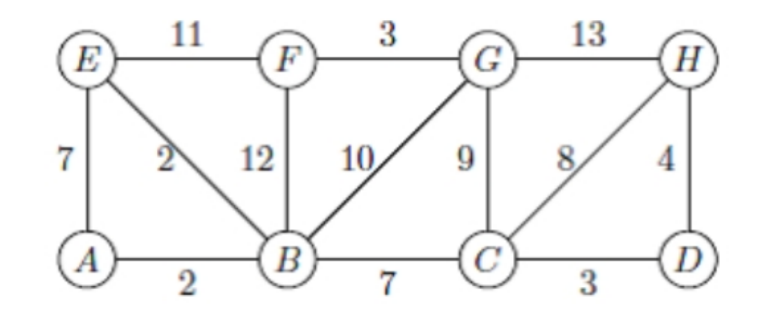

**Solución.**

Sea $N = \{A, B, C, D, E, F, G, H\}$ el conjunto de nodos de la red (grafo),

$$C_k = \text{conjunto de nodos que se han conectado en la iteración $k$}$$
y $$\overline{C_k} = \text{Conjunto de nodos que todavía se deben conectar en la iteración $k$}.$$

El algortimo comienza en:

$$C_1 = \{A\}$$
y $$\overline{C_1} = \{B, C, D, E, F, G, H\}$$

Iteración 2:

$$C_2 = \{A, B\}$$
y $$\overline{C_2} = \{C, D, E, F, G, H\}$$


Iteración 3:

$$C_3 = \{A, B, E\}$$
y $$\overline{C_3} = \{C, D, F, G, H\}$$

Iteración 4:

$$C_4 = \{A, B, E, C\}$$
y $$\overline{C_4} = \{D, F, G, H\}$$

Iteración 5:

$$C_5 = \{A, B, E, C, D\}$$
y $$\overline{C_5} = \{F, G, H\}$$

Iteración 6:

$$C_6 = \{A, B, E, C, D, H\}$$
y $$\overline{C_6} = \{F, G\}$$

Iteración 7:

$$C_7 = \{A, B, E, C, D, H, G\}$$
y $$\overline{C_7} = \{F\}$$

Iteración 8:

$$C_8 = \{A, B, E, C, D, H, G, F\} \rightarrow \text{Árbol de expansión mínimo}$$
y $$\overline{C_7} = \varnothing $$

Produciendo un costo total de $30$ unidades.

In [ ]:
install.packages("igraph")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# ============================================================
# ÁRBOL GENERADOR MÍNIMO (MST) CON IGRAPH
# ============================================================

# 1. INSTALAR Y CARGAR LIBRERÍA
# install.packages("igraph")  # Ejecutar solo una vez
library(igraph)

# ============================================================
# 2. CONSTRUCCIÓN DEL GRAFO
# ============================================================

# Definir aristas
edges <- c(
  "E","F",
  "F","G",
  "G","H",
  "E","A",
  "A","B",
  "B","C",
  "C","D",
  "F","B",
  "G","C",
  "H","D",
  "E","B",
  "B","G",
  "C","H"
)

# Crear grafo no dirigido
g <- graph(edges, directed = FALSE)

# Asignar pesos (en el mismo orden)
E(g)$weight <- c(
  11, 3, 13,
  7, 2, 7, 3,
  12, 9, 4,
  2, 10, 8
)

# ============================================================
# 3. DEFINIR LAYOUT (FORMA DEL GRAFO)
# ============================================================

layout_custom <- matrix(c(
  0,1,   # E
  1,1,   # F
  2,1,   # G
  3,1,   # H
  0,0,   # A
  1,0,   # B
  2,0,   # C
  3,0    # D
), byrow = TRUE, ncol = 2)

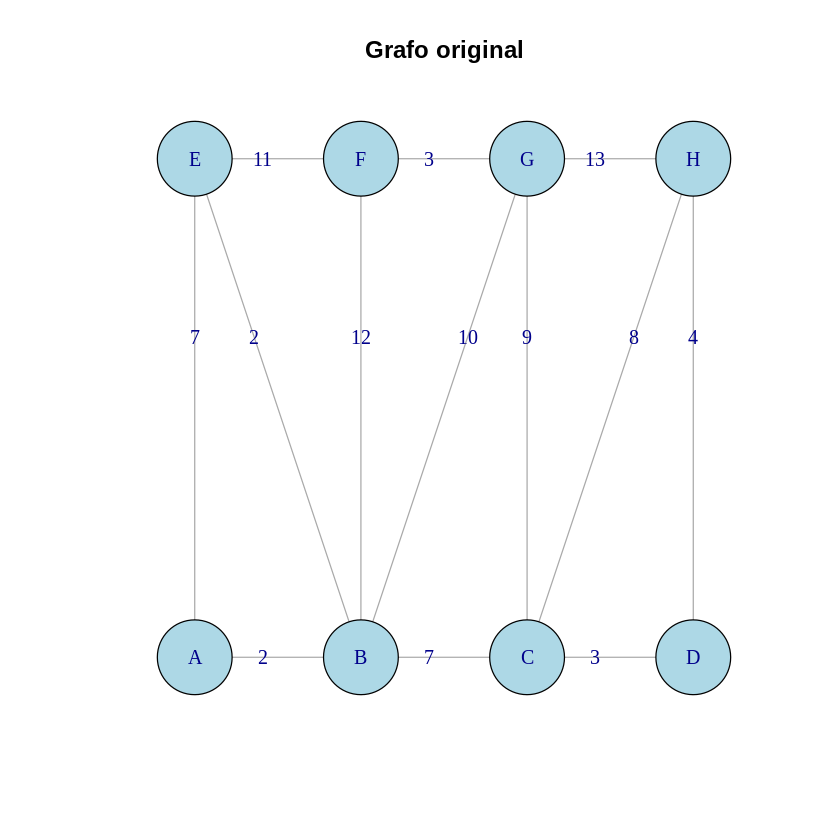

In [ ]:
# ============================================================
# 4. DIBUJAR GRAFO ORIGINAL
# ============================================================

plot(g,
     layout = layout_custom,
     edge.label = E(g)$weight,
     vertex.size = 30,
     vertex.color = "lightblue",
     main = "Grafo original")

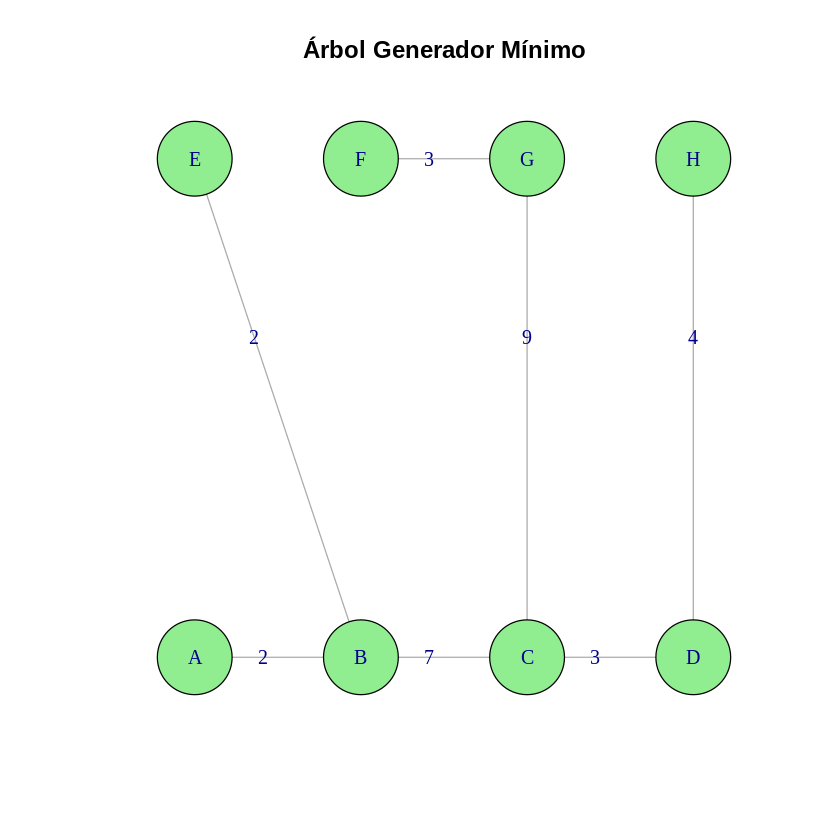

In [ ]:
# ============================================================
# 5. CALCULAR ÁRBOL GENERADOR MÍNIMO
# ============================================================

mst_g <- mst(g, weights = E(g)$weight)

# ============================================================
# 6. DIBUJAR SOLO EL MST
# ============================================================

plot(mst_g,
     layout = layout_custom,
     edge.label = E(mst_g)$weight,
     vertex.size = 30,
     vertex.color = "lightgreen",
     main = "Árbol Generador Mínimo")

Warning message:
“`get.edge.ids()` was deprecated in igraph 2.1.0.
ℹ Please use `get_edge_ids()` instead.”


[1] "Costo total del MST: 30"


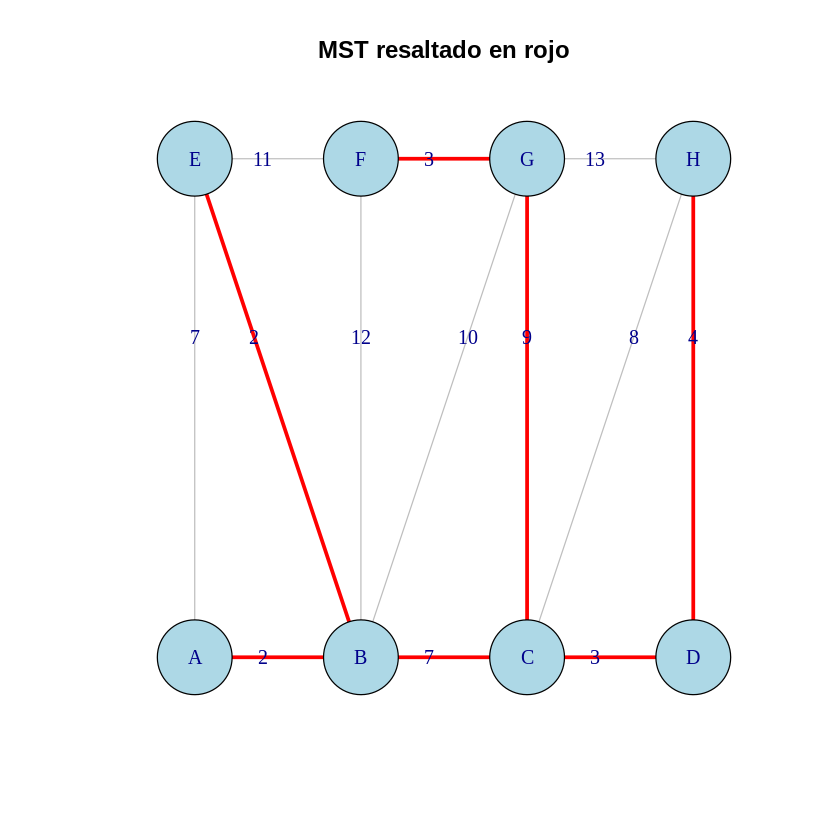

In [ ]:
# ============================================================
# 7. RESALTAR MST SOBRE EL GRAFO ORIGINAL
# ============================================================

# Colorear todas las aristas en gris
E(g)$color <- "gray"
E(g)$width <- 1

# Obtener aristas del MST
mst_edges <- as_edgelist(mst_g)

# Pintar en rojo las aristas del MST
for(i in 1:nrow(mst_edges)){
  id <- get.edge.ids(g, mst_edges[i,])
  E(g)[id]$color <- "red"
  E(g)[id]$width <- 3
}

# Dibujar resultado final
plot(g,
     layout = layout_custom,
     edge.label = E(g)$weight,
     vertex.size = 30,
     vertex.color = "lightblue",
     main = "MST resaltado en rojo")

# ============================================================
# 8. COSTO TOTAL DEL MST
# ============================================================

costo_total <- sum(E(mst_g)$weight)
print(paste("Costo total del MST:", costo_total))

Problema 14. Use el algoritmo de Dijsktra cuando el nodo fuente es 4 hacia el nodo terminal 2

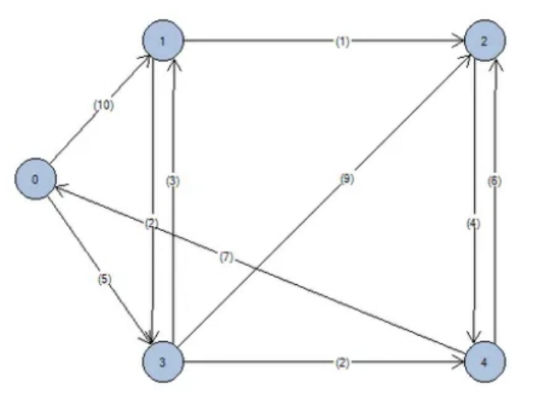

**Solución.**

Iteración 1

| Nodo | Etiqueta | Estado     |
|------|----------|------------|
| 4    | [0, -]   | Permanente |
| 2    | [6, 4]   | Temporal   |
| 0    | [7, 4]   | Temporal   |

Se llega al destino, aún así se continua para verificar óptimilidad (no es necesario dado que al observar el grafo se puede notar que ya se ha producido la menor distancia. Se hará con el fin de aplicar lo aprendido).

Iteración 2

El nodo $2$ sólo puede ir al nodo $4$, pero eso no es relevante por lo cual se analiza el nodo $0$

| Nodo | Etiqueta  | Estado     |
|------|-----------|------------|
| 4    | [0, -]    | Permanente |
| 2    | [6, 4]    | Permanente |
| 0    | [7, 4]    | Permanente |
| 1    | [7+10, 0] | Temporal   |
| 3    | [7+5, 0]  | Temporal   |

el nodo $3$ produce menor distancia, este puede ir al nodo $1$ y se produce un costo menor.

Iteración 3

| Nodo | Etiqueta  | Estado     |
|------|-----------|------------|
| 4    | [0, -]    | Permanente |
| 2    | [6, 4]    | Permanente |
| 0    | [7, 4]    | Permanente |
| 1    | [12+3, 3] | Temporal   |
| 3    | [7+5, 0]  | Permanete  |

Sólo queda un nodo temporal por lo que automaticamente se vuelve permanente.

En efecto, ir de $4 → 2$ es la ruta más corta. Por otro lado, las rutas más cortas entre el nodo fuente y todos lo demás nodos son los siguientes: $$4 → 0 \text{ costo = 7}$$ $$4 →0 →3 → 1 \text{ costo = 15}$$ $$4 → 0 → 3 \text{ costo = 12}.$$

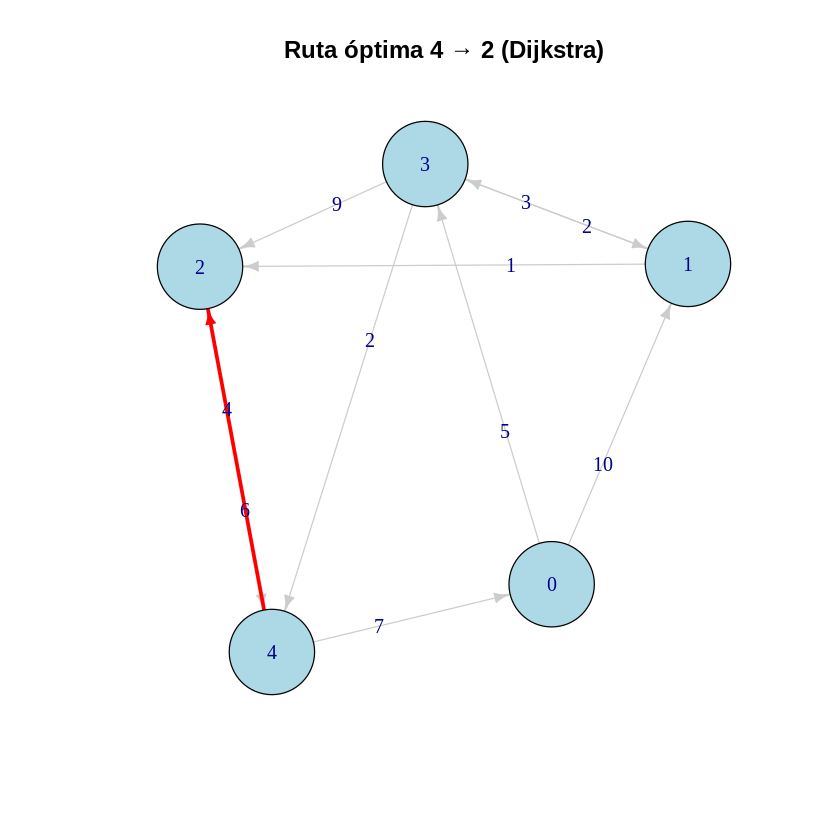

In [ ]:
library(igraph)

edges <- c("0","1",
           "0","3",
           "3","4",
           "3","1",
           "3","2",
           "1","2",
           "1","3",
           "2","4",
           "4","2",
           "4","0")

g_dir <- graph(edges = edges, directed = TRUE)
E(g_dir)$weight <- c(10, 5, 2, 3, 9, 1, 2, 4, 6, 7)

set.seed(123)
lay <- layout_with_fr(g_dir)

# Ruta mínima SOLO hacia el nodo 2
sp2 <- shortest_paths(g_dir,
                      from = "4",
                      to = "2",
                      weights = E(g_dir)$weight,
                      output = "epath")

edges_ruta <- unlist(sp2$epath)

# Colorear solo esa ruta
E(g_dir)$color <- "gray80"
E(g_dir)$width <- 1

E(g_dir)[edges_ruta]$color <- "red"
E(g_dir)[edges_ruta]$width <- 3

plot(g_dir,
     layout = lay,
     vertex.size = 35,
     vertex.color = "lightblue",
     edge.label = E(g_dir)$weight,
     edge.arrow.size = 0.6,
     main = "Ruta óptima 4 → 2 (Dijkstra)")

Problema 17. Aplique el algoritmo de Floyd. Genere en cada iteración las matrices de distancias $D_i$ y de Secuencias de nodos $S_i$.

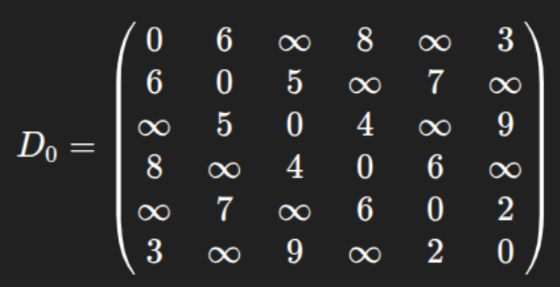

**Iteración 0.**

$$ D_0 = \begin{pmatrix}
0& 6& ∞ & 8& \infty &  3\\
6& 0& 5 & ∞& 7 &  ∞\\
∞& 5& 0 & 4& \infty &  9\\
8& ∞& 4 & 0 & 6 &  ∞\\
∞& 7& ∞ & 6& 0 &  2\\
3& ∞& 9 & ∞& 2 &  0
\end{pmatrix} \quad S_0 = \begin{pmatrix}
-& 2& 3 & 4& 5 &  6\\
1& -& 3 & 4& 5 &  6\\
1& 2& - & 4& 5 &  6\\
1& 2& 3 & - & 5 & 6\\
1& 2& 3 & 4& - &  6\\
1& 2& 3 & 4& 5 &  -
\end{pmatrix}$$

**Iteración 1.** Fijamos la fila y columna 1 como pivotes. Observe que los coeficientes $d_{24}, d_{42}, d_{26}, d_{62}, d_{46}$ y $d_{64}$ son los únicos que pueden mejorar. De aquí que

$$ D_1 = \begin{pmatrix}
0& 6& ∞ & 8& \infty &3\\
6& 0& 5 & 14& 7 &  9\\
∞& 5& 0 & 4& \infty &  9\\
8& 14&4 & 0 & 6 &  11\\
∞& 7& ∞ & 6& 0 &  2\\
3& 9& 9 & 11& 2 &  0
\end{pmatrix} \quad S_1 = \begin{pmatrix}
-& 2& 3 & 4& 5 &  6\\
1& -& 3 & 1& 5 &  1\\
1& 2& - & 4& 5 &  6\\
1& 1& 3 & - & 5 & 1\\
1& 2& 3 & 4& - &  6\\
1& 1& 3 & 1& 5 &  -
\end{pmatrix}$$


**Iteración 2.** Fijamos la fila y columna 2 como pivotes. Observe que los coeficientes $d_{13}, d_{31}, d_{15}, d_{51}, d_{35}$ y $d_{53}$ son los únicos que pueden mejorar. De aquí que

$$ D_2 = \begin{pmatrix}
0& 6& 11 & 8& 13 &3\\
6& 0& 5 & 14& 7 &  9\\
11& 5& 0 & 4& 12 &  9\\
8& 14&4 & 0 & 6 &  11\\
13& 7& 12 & 6& 0 &  2\\
3& 9& 9 & 11& 2 &  0
\end{pmatrix} \quad S_2 = \begin{pmatrix}
-& 2& 2 & 4& 2 &  6\\
1& -& 3 & 1& 5 &  1\\
2& 2& - & 4& 2 &  6\\
1& 1& 3 & - & 5 & 1\\
2& 2& 2 & 4& - &  6\\
1& 1& 3 & 1& 5 &  -
\end{pmatrix}$$


**Iteración 3.** Fijamos la fila y columna 3 como pivotes. Observe que los coeficientes $d_{24}$ y $d_{42}$ son los únicos que pueden mejorar. De aquí que

$$ D_3 = \begin{pmatrix}
0& 6& 11 & 8& 13 &3\\
6& 0& 5 & 9& 7 &  9\\
11& 5& 0 & 4& 12 &  9\\
8& 9&4 & 0 & 6 &  11\\
13& 7& 12 & 6& 0 &  2\\
3& 9& 9 & 11& 2 &  0
\end{pmatrix} \quad S_3= \begin{pmatrix}
-& 2& 2 & 4& 2 &  6\\
1& -& 3 & 3& 5 &  1\\
2& 2& - & 4& 2 &  6\\
1& 3& 3 & - & 5 & 1\\
2& 2& 2 & 4& - &  6\\
1& 1& 3 & 1& 5 &  -
\end{pmatrix}$$

**Iteración 4.** Fijamos la fila y columna 4 como pivotes. Observe que los coeficientes $d_{35}$ y $d_{53}$ son los únicos que pueden mejorar. De aquí que

$$ D_4 = \begin{pmatrix}
0& 6& 11 & 8& 13 &3\\
6& 0& 5 & 9& 7 &  9\\
11& 5& 0 & 4& 10 &  9\\
8& 9&4 & 0 & 6 &  11\\
13& 7& 10& 6& 0 &  2\\
3& 9& 9 & 11& 2 &  0
\end{pmatrix} \quad S_4 = \begin{pmatrix}
-& 2& 2 & 4& 2 &  6\\
1& -& 3 & 3& 5 &  1\\
2& 2& - & 4& 4 &  6\\
1& 3& 3 & - & 5 & 1\\
2& 2& 4 & 4& - &  6\\
1& 1& 3 & 1& 5 &  -
\end{pmatrix}$$

**Iteración 5.** Fijamos la fila y columna 5 como pivotes. Observe que los coeficientes $d_{46}$ y $d_{64}$ son los únicos que pueden mejorar. De aquí que

$$ D_5 = \begin{pmatrix}
0& 6& 11 & 8& 13 &3\\
6& 0& 5 & 9& 7 &  9\\
11& 5& 0 & 4& 10 &  9\\
8& 9&4 & 0 & 6 &  8\\
13& 7& 10& 6& 0 &  2\\
3& 9& 9 & 8& 2 &  0
\end{pmatrix} \quad S_5 = \begin{pmatrix}
-& 2& 2 & 4& 2 &  6\\
1& -& 3 & 3& 5 &  1\\
2& 2& - & 4& 4 &  6\\
1& 3& 3 & - & 5 & 5\\
2& 2& 4 & 4& - &  6\\
1& 1& 3 & 5& 5 &  -
\end{pmatrix}$$

**Iteración 6.** Fijamos la fila y columna 6 como pivotes. Observe que los coeficientes $d_{15}$ y $d_{51}$ son los únicos que pueden mejorar. De aquí que

$$ D_6 = \begin{pmatrix}
0& 6& 11 & 8& 5 &3\\
6& 0& 5 & 9& 7 &  9\\
11& 5& 0 & 4& 10 &  9\\
8& 9&4 & 0 & 6 &  8\\
5& 7& 10& 6& 0 &  2\\
3& 9& 9 & 8& 2 &  0
\end{pmatrix} \quad S_6 = \begin{pmatrix}
-& 2& 2 & 4& 6 &  6\\
1& -& 3 & 3& 5 &  1\\
2& 2& - & 4& 4 &  6\\
1& 3& 3 & - & 5 & 5\\
6& 2& 4 & 4& - &  6\\
1& 1& 3 & 5& 5 &  -
\end{pmatrix}.$$

Las matrices finales, $D_6$ y $S_6$ contienen toda la información necesaria para determinar la ruta más corta entre dos nodos cualesquiera de la red.

In [ ]:
# ============================================================
# FLOYD-WARSHALL DESDE MATRIZ (Verificar)
# ============================================================

# Usamos Inf para infinito
D <- matrix(c(
  0,6,Inf,8,Inf,3,
  6,0,5,Inf,7,Inf,
  Inf,5,0,4,Inf,9,
  8,Inf,4,0,6,Inf,
  Inf,7,Inf,6,0,2,
  3,Inf,9,Inf,2,0
), nrow=6, byrow=TRUE)

n <- nrow(D)

# Matriz de siguientes nodos
S <- matrix(0, n, n)

# Inicialización
for(i in 1:n){
  for(j in 1:n){
    if(i != j && D[i,j] < Inf){
      S[i,j] <- j
    }
  }
}

# Floyd-Warshall
for(k in 1:n){
  for(i in 1:n){
    for(j in 1:n){
      if(D[i,k] + D[k,j] < D[i,j]){
        D[i,j] <- D[i,k] + D[k,j]
        S[i,j] <- S[i,k]
      }
    }
  }
}

# Resultado final
print("Matriz de distancias óptimas:")
print(D)

print("Matriz de secuencias:")
print(S)

[1] "Matriz de distancias óptimas:"
     [,1] [,2] [,3] [,4] [,5] [,6]
[1,]    0    6   11    8    5    3
[2,]    6    0    5    9    7    9
[3,]   11    5    0    4   10    9
[4,]    8    9    4    0    6    8
[5,]    5    7   10    6    0    2
[6,]    3    9    9    8    2    0
[1] "Matriz de secuencias:"
     [,1] [,2] [,3] [,4] [,5] [,6]
[1,]    0    2    2    4    6    6
[2,]    1    0    3    3    5    1
[3,]    2    2    0    4    4    6
[4,]    1    3    3    0    5    5
[5,]    6    2    4    4    0    6
[6,]    1    1    3    5    5    0


Problema 24. Use el algoritmo de flujo máximo sobre el grafo definido por la siguiente información.

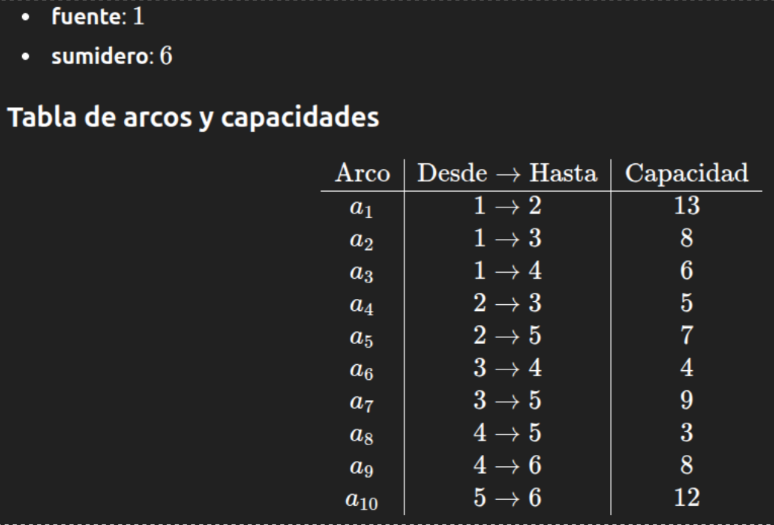

**Solución.**

Iteración 1. Observe el siguiente camino más corto $$1 →4 → 6$$
las capacidades son $1 → 4 = 6$ y $4→6 = 8$. Entonces la capacidad mínima es $F_1 = 6$.


Ahora las capacidades han cambiado:

| Arco | Desde | Hasta | Capacidad |
| ---- | ----- | ----- | --------- |
| a₁   | 1     | 2     | 13        |
| a₂   | 1     | 3     | 8         |
| a₃   | 1     | 4     | 0         |
| a₄   | 2     | 3     | 5         |
| a₅   | 2     | 5     | 7         |
| a₆   | 3     | 4     | 4         |
| a₇   | 3     | 5     | 9         |
| a₈   | 4     | 5     | 3         |
| a₉   | 4     | 6     | 2         |
| a₁₀  | 5     | 6     | 12        |

Iteración 2. El nuevo camino es el siguiente $$1→3→5→6,$$ observe la tabla para verificar que la capacidad mínima es $1→3 =8,$ entonces $F_2 = 8$. Ahora las capacidades han cambiado:

| Arco | Desde | Hasta | Capacidad |
| ---- | ----- | ----- | --------- |
| a₁   | 1     | 2     | 13        |
| a₂   | 1     | 3     | 0         |
| a₃   | 1     | 4     | 0         |
| a₄   | 2     | 3     | 5         |
| a₅   | 2     | 5     | 7         |
| a₆   | 3     | 4     | 4         |
| a₇   | 3     | 5     | 1         |
| a₈   | 4     | 5     | 3         |
| a₉   | 4     | 6     | 2         |
| a₁₀  | 5     | 6     | 4         |

Iteración 3. Otro camino es el siguiente $$1 →2→5→6,$$ la capacidad mínima es $F_3 = 4$. Capacidades nuevas
| Arco | Desde | Hasta | Capacidad |
| ---- | ----- | ----- | --------- |
| a₁   | 1     | 2     | 9        |
| a₂   | 1     | 3     | 0         |
| a₃   | 1     | 4     | 0         |
| a₄   | 2     | 3     | 5         |
| a₅   | 2     | 5     | 3         |
| a₆   | 3     | 4     | 4         |
| a₇   | 3     | 5     | 1         |
| a₈   | 4     | 5     | 3         |
| a₉   | 4     | 6     | 2         |
| a₁₀  | 5     | 6     | 0         |

Iteración 4. Nuevo camino $1→2→3→4→6$, con capacidad mínima $F_4 = 2$. Capacidades nuevas

| Arco | Desde | Hasta | Capacidad |
| ---- | ----- | ----- | --------- |
| a₁   | 1     | 2     | 7        |
| a₂   | 1     | 3     | 0         |
| a₃   | 1     | 4     | 0         |
| a₄   | 2     | 3     | 3         |
| a₅   | 2     | 5     | 3         |
| a₆   | 3     | 4     | 2         |
| a₇   | 3     | 5     | 1         |
| a₈   | 4     | 5     | 3         |
| a₉   | 4     | 6     | 0         |
| a₁₀  | 5     | 6     | 0         |


Fin del algoritmo. No existen más caminos aumentantes. Flujo máximo igual a $20.$




Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Warning message:
“`graph()` was deprecated in igraph 2.1.0.
ℹ Please use `make_graph()` instead.”


IGRAPH c044329 D--- 6 10 -- 
+ attr: capacity (e/n)
+ edges from c044329:
 [1] 1->2 1->3 1->4 2->3 2->5 3->4 3->5 4->5 4->6 5->6
          RESULTADO DEL FLUJO MÁXIMO
Flujo máximo:  20 

Flujo por arco:
 [1] 12  4  4  5  7  4  5  0  8 12


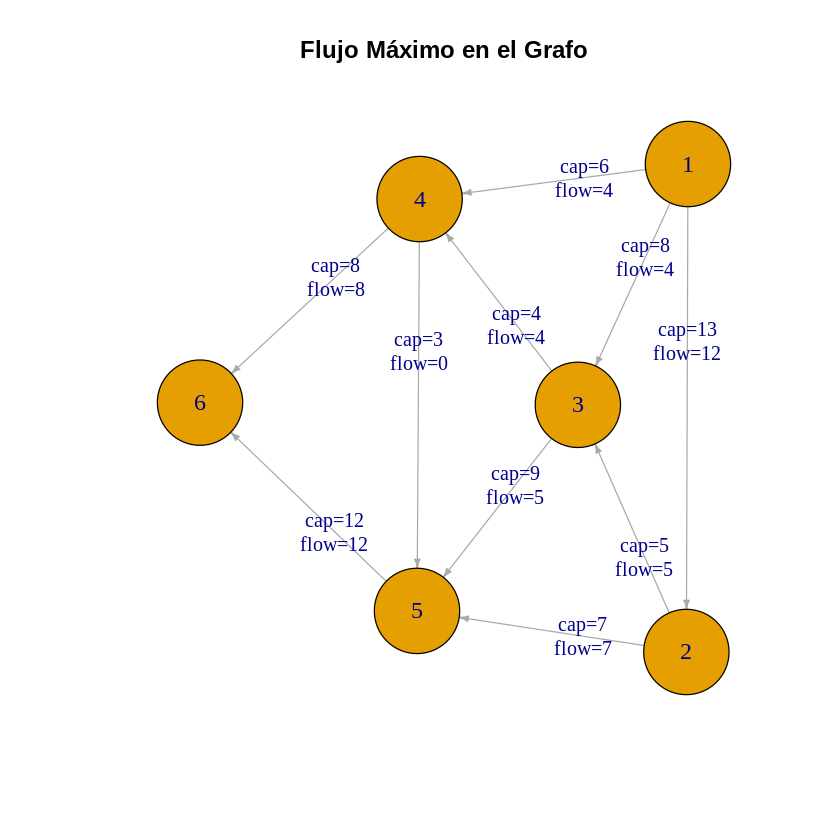

In [ ]:
library(igraph)

# ============================================================
# 1. Definir arcos y capacidades del problema
# ============================================================

# Lista de arcos dirigidos (desde, hasta)
edges <- c(
  1,2,   # a1
  1,3,   # a2
  1,4,   # a3
  2,3,   # a4
  2,5,   # a5
  3,4,   # a6
  3,5,   # a7
  4,5,   # a8
  4,6,   # a9
  5,6    # a10
)

# Capacidades en el mismo orden de los arcos
capacity <- c(13,8,6,5,7,4,9,3,8,12)

# Crear el grafo dirigido
g <- graph(edges = edges, directed = TRUE)

# Asignar capacidades
E(g)$capacity <- capacity

# Verificar grafo
print(g)

# ============================================================
# 2. Calcular flujo máximo fuente=1, sumidero=6
# ============================================================

mf <- max_flow(g, source = 1, target = 6)

cat("===============================================\n")
cat("          RESULTADO DEL FLUJO MÁXIMO\n")
cat("===============================================\n")
cat("Flujo máximo: ", mf$value, "\n\n")

cat("Flujo por arco:\n")
print(mf$flow)

# ============================================================
# 3. Dibujar grafo con capacidades y flujos
# ============================================================

# Etiquetas de arcos: capacidad y flujo obtenido
edge_labels <- paste0("cap=", E(g)$capacity, "\nflow=", mf$flow)

plot(
  g,
  edge.label = edge_labels,
  vertex.size = 35,
  vertex.label.cex = 1.2,
  edge.arrow.size = 0.35,
  main = "Flujo Máximo en el Grafo"
)